In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score, precision_recall_curve, auc, roc_auc_score,average_precision_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
from scipy.stats import uniform, loguniform, randint

# 1. Load Data

In [2]:
df_raw = pd.read_csv('clean_data.csv')
df = df_raw.copy()

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,hour_of_day,day_of_week,accountDrained,isHighAmount
0,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0.00,181.0,1,0,1,0
1,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0.00,21363.0,1,0,1,0
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,-213808.94,182703.5,1,0,1,0
3,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,-214605.30,237735.3,1,0,1,0
4,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,-300850.89,-2401220.0,1,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2770409 entries, 0 to 2770408
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   step              int64  
 1   type              object 
 2   amount            float64
 3   nameOrig          object 
 4   oldbalanceOrg     float64
 5   newbalanceOrig    float64
 6   nameDest          object 
 7   oldbalanceDest    float64
 8   newbalanceDest    float64
 9   isFraud           int64  
 10  errorBalanceOrig  float64
 11  errorBalanceDest  float64
 12  hour_of_day       int64  
 13  day_of_week       int64  
 14  accountDrained    int64  
 15  isHighAmount      int64  
dtypes: float64(7), int64(6), object(3)
memory usage: 338.2+ MB


# 2. Data Preprocessing

In [5]:
df = pd.get_dummies(df,columns=['type'], drop_first=True, dtype=int)

In [6]:
df = df.drop(columns=['step','nameOrig'])

# 3. Split Data

In [7]:
X = df.drop(columns='isFraud')
y = df['isFraud']
X_train, X_test, y_train, y_test  = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train = X_train.copy()
X_test = X_test.copy()

dest_counts = X_train['nameDest'].value_counts()
X_train['destTransactionCount'] = X_train['nameDest'].map(dest_counts)
X_test['destTransactionCount'] = X_test['nameDest'].map(dest_counts).fillna(1)

X_train = X_train.drop(columns=['nameDest'])
X_test = X_test.drop(columns=['nameDest'])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 3.1  Hyperparameter Tuning Subset (10%)

In [8]:
X_tune, _, y_tune,_ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=42)

# 4. Result Function

In [9]:
def results(model_name, y_test, y_pred, y_scores=None):
    print(f"  {model_name}")
    print("--------------")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred):.4f}")
    if y_scores is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_test, y_scores):.4f}")
        print(f"PR-AUC:    {average_precision_score(y_test, y_scores):.4f}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
def feature_importance(model, feature_names, title, top_n=15):
    estimator = model
    importances = estimator.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    fi.plot(kind='barh', color='teal')
    plt.title(f'Feature Importances - {title}', fontsize=14)
    plt.xlabel('Absolute coefficient value', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
def coefficients(model, feature_names, top_n=15):
    coefs = model.named_steps['log_reg'].coef_[0]
    fi = pd.Series(coefs, index=feature_names)
    fi = fi.abs().sort_values(ascending=True).tail(int(top_n))
    plt.figure(figsize=(8,6))
    fi.plot(kind='barh')
    plt.title('Feature Importance - Logistic Regression Tuned')
    plt.xlabel('Absolute coefficient value')
    plt.tight_layout()
    plt.show()

# 5. Logisitic Regression (Baseline Model)

## 5.1 First Model (Default Settings)

In [10]:
model_log = make_pipeline(StandardScaler(), LogisticRegression())
model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
y_score_log = model_log.predict_proba(X_test)[:, -1]

## 5.2 Model Results

  Logistic Regression - Default
--------------
Precision: 0.9188
Recall:    0.5782
F1:        0.7097
ROC-AUC:   0.9882
PR-AUC:    0.7779


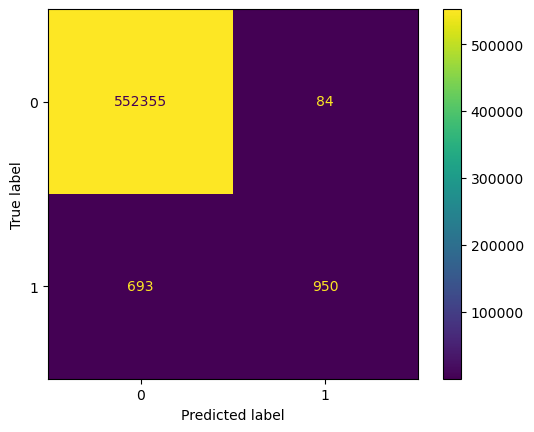

In [11]:
results("Logistic Regression - Default", y_test, y_pred_log, y_score_log)

## 5.3 Logistic Regression - Tuned

In [12]:
pipe_log_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=7))
])
param_log_tuned = {
    'log_reg__C': loguniform(0.001, 100),
    'log_reg__penalty': ['l1','l2','elasticnet'],
    'log_reg__solver': ['saga'],
    'log_reg__l1_ratio': uniform(0,1),
    'log_reg__max_iter': [2000,5000],
    'log_reg__class_weight': ['balanced', None]
}
search_log_tuned = RandomizedSearchCV(estimator=pipe_log_tuned,
                           param_distributions = param_log_tuned,
                           n_iter = 20,
                           cv=skf,
                           scoring='average_precision',
                           n_jobs=-1,
                           random_state=42,
                           verbose=1)
search_log_tuned.fit(X_tune, y_tune)
print('The best parameters:', search_log_tuned.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\Oliwer\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


The best parameters: {'log_reg__C': np.float64(42.982762978218666), 'log_reg__class_weight': 'balanced', 'log_reg__l1_ratio': np.float64(0.9218742350231168), 'log_reg__max_iter': 5000, 'log_reg__penalty': 'l2', 'log_reg__solver': 'saga'}


In [13]:
best_model_log_tuned = search_log_tuned.best_estimator_
y_pred_log_tuned = best_model_log_tuned.predict(X_test)
y_scores_log_tuned = search_log_tuned.best_estimator_.predict_proba(X_test)[:, 1]

## 5.5 Model Results

  Logistic Regression - Tuned
--------------
Precision: 0.1001
Recall:    0.9726
F1:        0.1814
ROC-AUC:   0.9928
PR-AUC:    0.7844


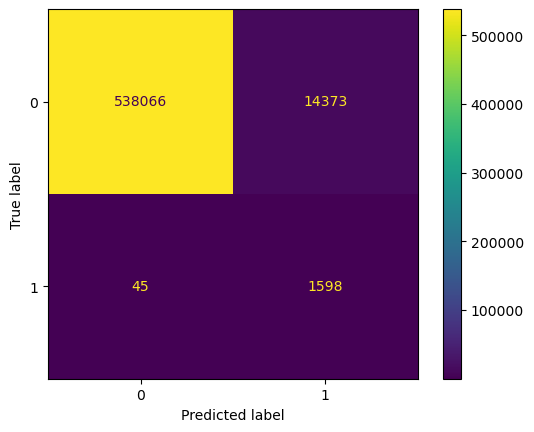

In [14]:
results("Logistic Regression - Tuned", y_test, y_pred_log_tuned, y_scores_log_tuned)


# 5.6 Feature Importance

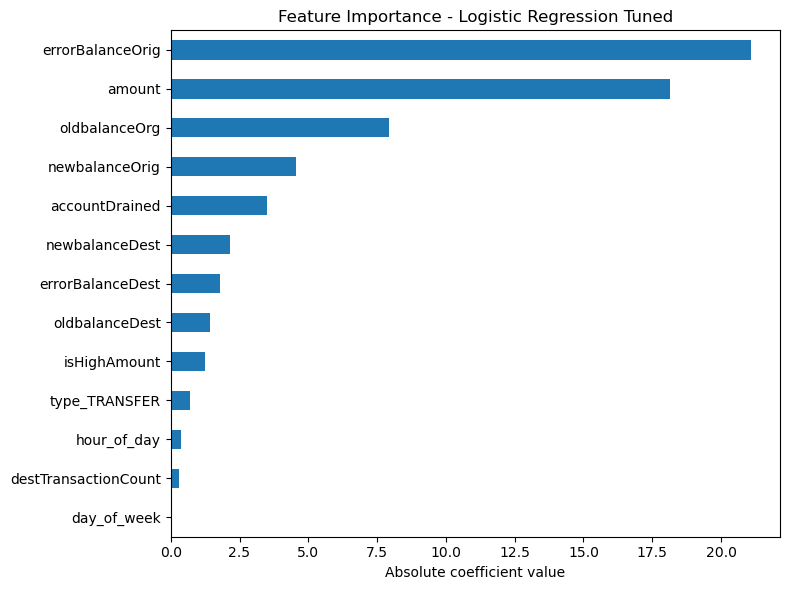

In [15]:
coefficients(best_model_log_tuned ,X_tune.columns)

# 6. LGBMClassifier

## 6.1 First Model (Default Settings)

In [16]:
model_lgbc = LGBMClassifier()
model_lgbc.fit(X_train,y_train)
y_pred_lgbc = model_lgbc.predict(X_test)
y_score_lgbc = model_lgbc.predict_proba(X_test)[:, -1]

[LightGBM] [Info] Number of positive: 6570, number of negative: 2209757
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1877
[LightGBM] [Info] Number of data points in the train set: 2216327, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002964 -> initscore=-5.818124
[LightGBM] [Info] Start training from score -5.818124


## 6.2 Model Results

  LGBMClassifier - Default
--------------
Precision: 0.6032
Recall:    0.5819
F1:        0.5923
ROC-AUC:   0.6515
PR-AUC:    0.3623


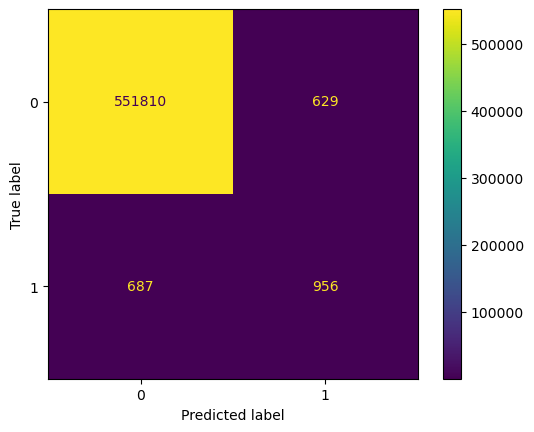

In [17]:
results("LGBMClassifier - Default", y_test, y_pred_lgbc, y_score_lgbc)

## 6.3 LGBMClassifier - Tuned

In [18]:

param_lgbm_tuned = {
    'n_estimators':      [500, 1000, 2000],
    'max_depth':         [4, 6, 8, -1],
    'learning_rate':     loguniform(0.01, 0.3),
    'num_leaves':        [31, 63, 127],
    'min_child_samples': [20, 50, 100],
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'class_weight':      ['balanced', None]
}
search_lgbm_tuned = RandomizedSearchCV(
                        estimator=LGBMClassifier(
                         random_state=42,
                         n_jobs = -1,
                         verbose=-1),
    param_distributions=param_lgbm_tuned,
    n_iter=50,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_lgbm_tuned.fit(X_tune, y_tune)
print('The best parameters:', search_lgbm_tuned.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
The best parameters: {'class_weight': None, 'colsample_bytree': np.float64(0.6643232205669994), 'learning_rate': np.float64(0.064646697464924), 'max_depth': 6, 'min_child_samples': 100, 'n_estimators': 500, 'num_leaves': 31, 'subsample': np.float64(0.6703701010709381)}


In [19]:
best_model_lgbm_tuned = search_lgbm_tuned.best_estimator_
y_pred_lgbm_tuned = best_model_lgbm_tuned.predict(X_test)
y_scores_lgbm_tuned = search_lgbm_tuned.best_estimator_.predict_proba(X_test)[:, 1]

## 5.4 Model Results

  LGBMClassifier - Tuned
--------------
Precision: 0.9988
Recall:    0.9927
F1:        0.9957
ROC-AUC:   0.9989
PR-AUC:    0.9965


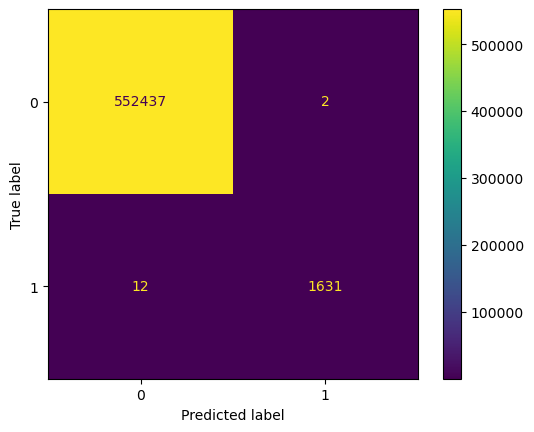

In [20]:
results("LGBMClassifier - Tuned", y_test, y_pred_lgbm_tuned, y_scores_lgbm_tuned)

# 5.5 Feature Importance

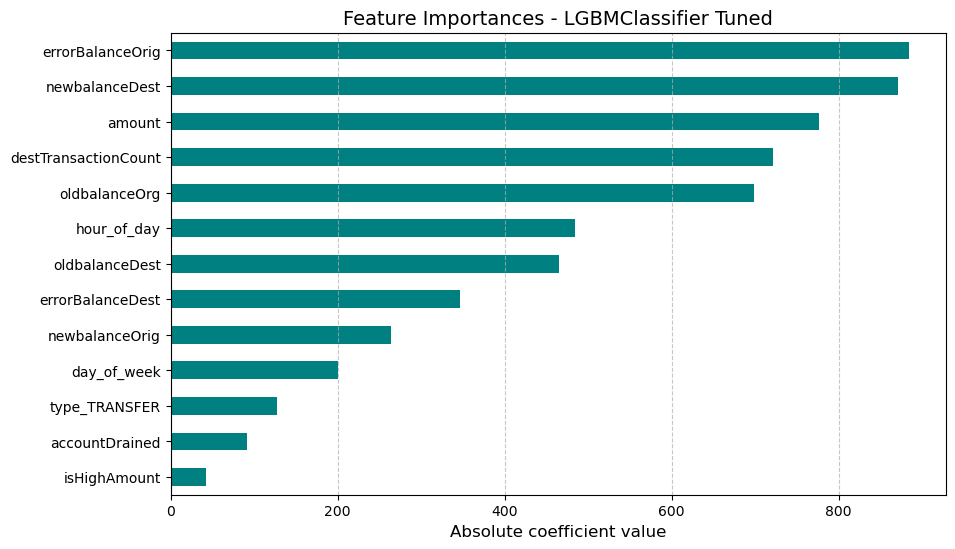

In [21]:
feature_importance(best_model_lgbm_tuned, X_tune.columns, "LGBMClassifier Tuned")

# 7. Isolation Forest

## 7.1 First Model (Default Settings)

In [22]:
model_if = IsolationForest()
model_if.fit(X_train,y_train)
y_pred_if = (model_if.predict(X_test) == -1).astype(int)
y_score_if = -model_if.score_samples(X_test)

## 7.2 Model Results

  Isolation Forest - Default
--------------
Precision: 0.0154
Recall:    0.6488
F1:        0.0301
ROC-AUC:   0.8697
PR-AUC:    0.0340


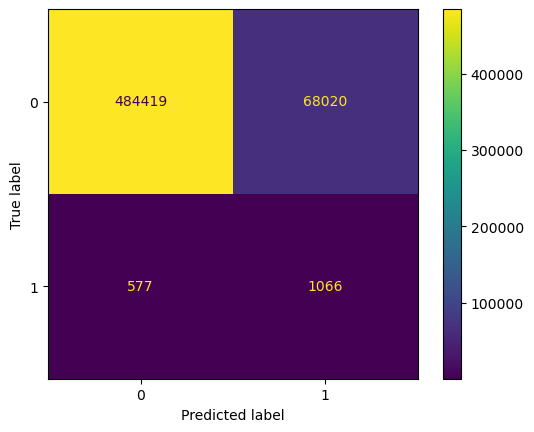

In [23]:
results("Isolation Forest - Default", y_test, y_pred_if, y_score_if)

## 7.3 Isolation Forest - Tuned

In [24]:
param_if_tuned = {
    'n_estimators':  [100, 200, 500],
    'max_samples':   ['auto', 0.5, 0.8],
    'contamination': [0.001, 0.005, 0.01, 0.02],
    'max_features':  [0.5, 0.8, 1.0]
}

search_if_tuned = RandomizedSearchCV(
    estimator=IsolationForest(random_state=42),
    param_distributions=param_if_tuned,
    n_iter=30,
    cv=skf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_if_tuned.fit(X_tune, y_tune)
print('The best parameters:', search_if_tuned.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
The best parameters: {'n_estimators': 200, 'max_samples': 'auto', 'max_features': 0.8, 'contamination': 0.001}


In [25]:
best_model_if_tuned = search_if_tuned.best_estimator_
y_pred_if_tuned = (best_model_if_tuned.predict(X_test) == -1).astype(int)
y_score_if_tuned = -best_model_if_tuned.score_samples(X_test)

## 7.4 Model Results

  Isolation Forest - Tuned
--------------
Precision: 0.0016
Recall:    0.0006
F1:        0.0009
ROC-AUC:   0.8505
PR-AUC:    0.0206


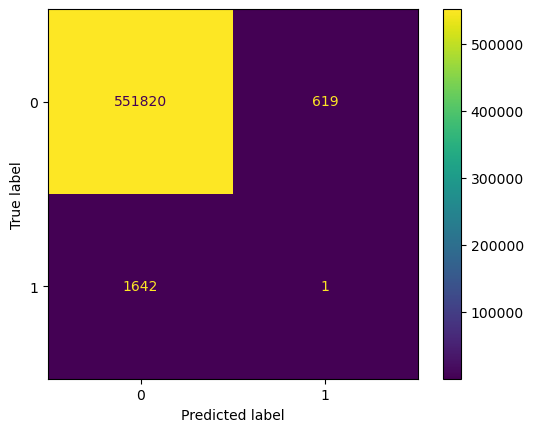

In [26]:
results("Isolation Forest - Tuned", y_test, y_pred_if_tuned, y_score_if_tuned)

# 7.5 Feature Importance

In [27]:
import shap

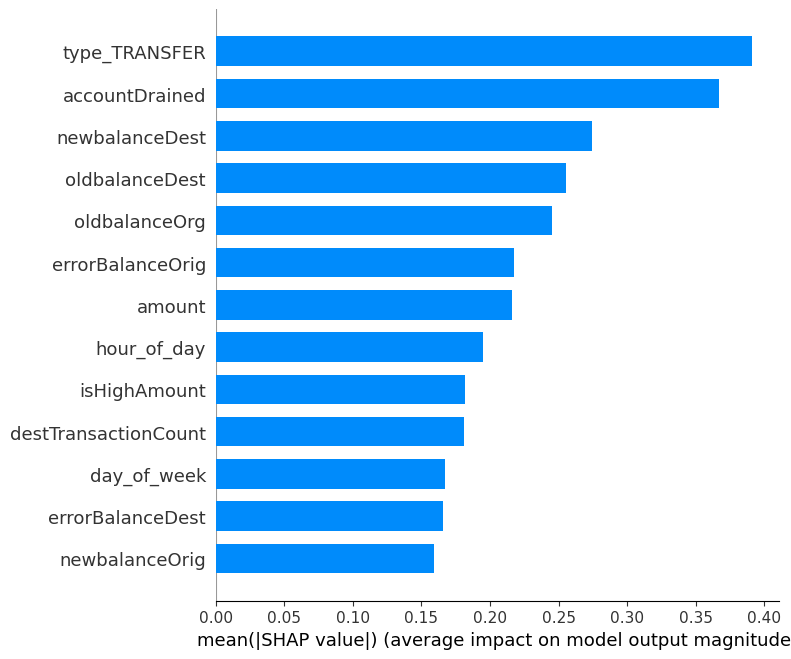

In [28]:
explainer = shap.TreeExplainer(best_model_if_tuned)
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

In [29]:
# 8. 